# Accuracy Analyzer Tool
The accuracy analyzer is used to debug accuracy issues with a given model on AIC with one specific input data.

The tool does the accuracy debugging by comparing raw tensor values w.r.t to some reference framework. The reference framework could be Onnx Runtime for onnx models, the AIC interpreter, Tensorflow and Caffe

Please see below the high level workflow for executing your model on AIC100. Accuracy Analzer tool can be used in the stage highlighted in red. 

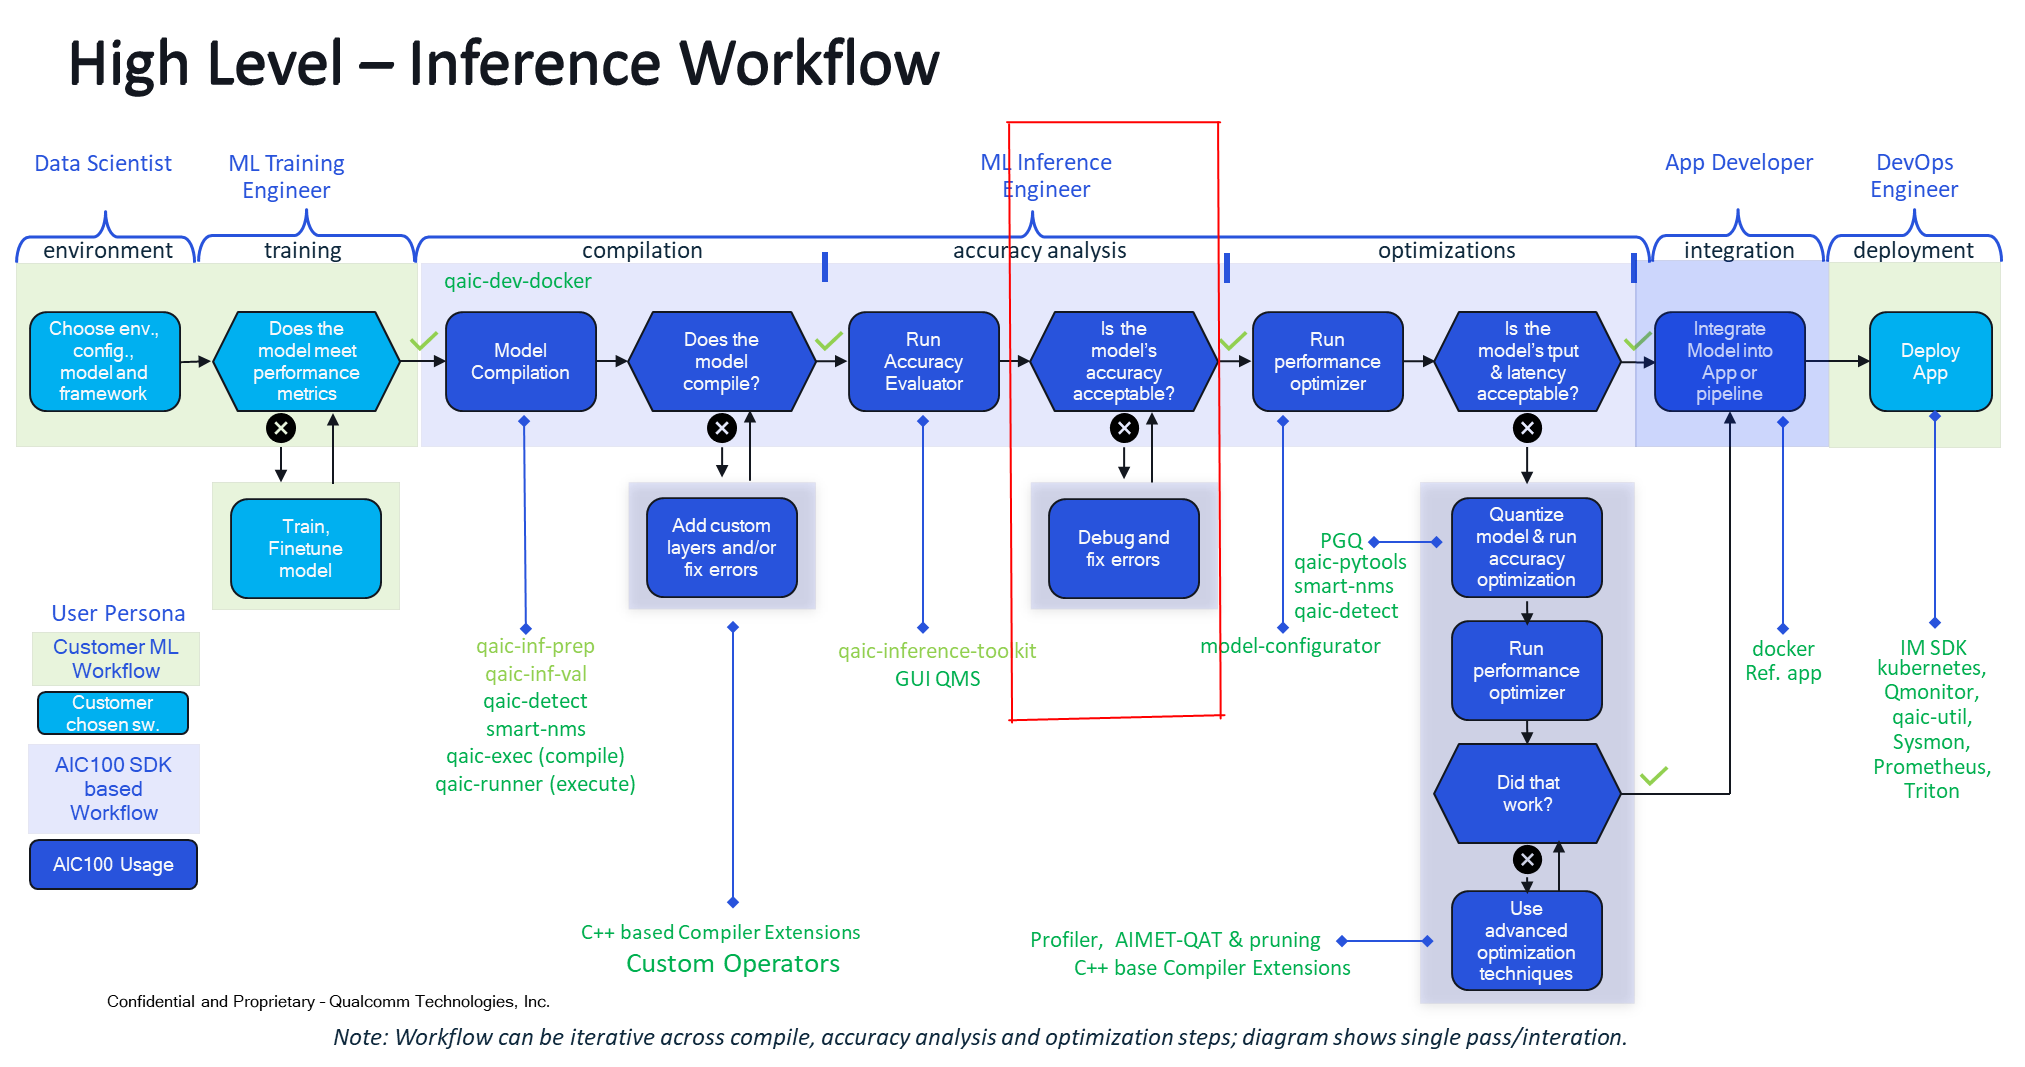

## Requirements 
- Qualcomm Cloud AI 100 device
- Qualcomm AI 100 Software Development Kit >= 1.7
   - Platform SDK
   - Apps SDK 
- Python 3.8*-devel 
     - Centos: yum install python3-devel
     - Ubuntu: apt-get install python3-dev

### Setting up the Environment

#### Adding Kernel to Jupyter Notebook/Lab 


In [2]:
!/opt/qti-aic/dev/python/qaic-env/bin/python -m pip install ipykernel 
!source /opt/qti-aic/dev/python/qaic-env/bin/activate

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.2/152.2 kB 20.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 23.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.8/797.8 kB 84.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 17.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 42.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.9/426.9 kB 35.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.4/117.4 kB 45.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 100.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.8/385.8 kB 154.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.0/59.0 kB 106.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━



## Tool usage and options

### Comparators

This option enables user to choose what kind of comparison to use to evaluate layerwise similarity between AIC and reference outputs. One can pass multiple comparators with this option

If the match is not 100%, its marked as a mismatched layer and the model shall be partitioned at that layer when using layerwise snooping.

Valid options:

 abs | rme | avg | l1norm | l2norm | cos | kld | std 

**Description of each comparator and its formulae:**

*Note:* Here op1 and op1 are the numpy output tensors from aic and reference platform 

**abs:**  
evaluates the absolute percent mismatch between two tensors (elementwise). Uses a tolerance threshold to control the allowed % deviation.
```
match = np.allclose(op1, op2, rtol=self._tol, equal_nan=True)
tdiff = np.isclose(op1, op2, rtol=self._tol, equal_nan=True)
common = op1[tdiff]
match_percent = (common.shape[0] * 100) / op2.shape[0]
```

**rme:**
Evaluates the RMSE between the two tensors.
```
rmse = np.linalg.norm(op2 - op1) / np.sqrt(len(op1))
match_percent = 100 - rmse
 ```       

**avg:**
Evaluates the error between the two tensors by dividing the absolute gap by average value of the tensors.
```
avg_value = np.nan_to_num(max(np.average(np.absolute(op1)), np.average(np.absolute(op2))))
if (avg_value != 0):
    avg_error = np.average(abs(op1 - op2)) / avg_value
else:
    avg_error = 0.0
avg_error *= 100.0
match_percent = 100 - avg_error
```

**l1norm, l2norm:**
Evaluates the L1 and L2 norm of the two tensors.
```
ord = 1 for l1norm
ord = 2 for l2nor  
diff = np.linalg.norm(op2 - op1, ord=1)
ref_norm = np.linalg.norm(op1, ord=1)
match_percent = 100 - (diff * 100 / ref_norm)
```

**cos:**
Evaluates the cosine similarity between the two tensors
```
cos_sim = np.dot(op1, op2)/ (np.linalg.norm(op1) * np.linalg.norm(op2))
match_percent = (1+cos_sim)/2 * 100
```

**kld:**
Evaluates the KL Divergence between the two tensors
```
kld = entropy(op1, op2, base=2)
```

**std:**
Evaluates the Relative Standard deviation between the two tensors Comparator is enabled by default and the tool supports various set of in built comparators.By default, average comparator is used.
```
std1 = np.std(op1)
std2 = np.std(op2)
pct_change = (abs(std2 - std1) / std1)*100
```


In [11]:
!source env/bin/activate
!pip install -r requirements.txt
!optimum-cli export onnx --model bert-base-cased --cache_dir model_files/cased --opset 11 --task question-answering generatedModels/ONNX/cased

Badly placed ()'s.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com



[notice] A new release of pip is available: 23.1.1 -> 23.1.2
[notice] To update, run: pip install --upgrade pip
2023-05-11 15:58:22.481658: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-05-11 15:58:22.481688: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
Framework not specified. Using pt to export to ONNX.
Some weights of the model checkpoint at bert-base-cased were not used when initializing BertForQuestionAnswering: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializin

In [3]:
# Get the defaults from SDK into current work directory if doesnt exist.
import os
import shutil
import pandas as pd
import sys
    

cwd = os.getcwd()
# delete old log directories
if os.path.exists(os.path.join(cwd , 'log_dir')):
    shutil.rmtree(os.path.join(cwd , 'log_dir'))
    
device_id = '0'
model_path = './generatedModels/ONNX/cased/model.onnx'
list_file = './list.txt'
input_file = './inputFiles/input_ids.raw,./inputFiles/input_mask.raw,./inputFiles/segment_ids.raw'

pgq_log = os.path.join(cwd ,'log_dir/pgq_log_dir')


In [2]:
import sys
assert sys.executable  == '/opt/qti-aic/dev/python/qaic-env/bin/python'
!/opt/qti-aic/tools/qaic-version-util
!{sys.executable} --version

platform:AIC.1.9.1.25
apps:AIC.1.9.1.25
factory:not found
Python 3.8.16


# PGQ Sweep
This strategy is useful to identify the best possible PGQ combination. In this strategy, we do Oneshot snooping over all the possible PGQ combinations and identify the best possible combination. This is a good starting point to use the accuracy analyzer. After identifying the best possible combination user can try our various other strategies and snooping methods to identifying the sensitive nodes/sub-graphs. User can reduce the combinations to search by giving custom combinations with pgq-options parameter.

**Note:** This step is not required if user has results of Accuracy Evaluator

## Executing pgq sweep:

In [5]:
import sys
assert sys.executable  == '/opt/qti-aic/dev/python/qaic-env/bin/python'
!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-analyzer.py \
        -model {model_path} \
        -input-list {list_file} \
        -work-dir {pgq_log} \
        -reference onnxrt \
        -precision int8 \
        -onnx-symbol sequence_length:128 \
        -strategy pgq-sweep 

/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
INFO: Caffe engine is unsupported in this environment.
INFO: QAIC Model Analyzer
INFO: Cleaned and Optimized model is saved at /local/mnt/workspace/Rohan/Trainings/Accuracy_Analyzer_notebooks/Analyzer_demo_bert/log_dir/pgq_log_dir/cleanmodel.onnx
INFO: Total no of nodes in the cleaned graph : 623
INFO: Node types and count in the cleaned graph:
   op_type  count
       Add    173
    MatMul     97
ReduceMean     50
       Mul     50
       Div     49
   Reshape     48
 Transpose     48
       Sub     26
       Pow     25
      Sqrt     25
   Softmax     12
       Erf     12
    Gather      2
 Unsqueeze      2
   Squeeze      2
      Cast      1
     Split      1
INFO: Snooping all intermediate outputs of model
INFO: Captured reference onnxrt session data
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-pa

### PGQ sweep result:
Best PGQ profile : quantization-schema:symmetric_with_uint8, quantization-calibration: None, channelwise: True, percentile-calibration-value: None

In [6]:
import pandas as pd

pd.set_option("display.max_rows", None, "display.max_columns", None)
csv_path = os.path.join(cwd ,'log_dir/pgq_log_dir/pgq_sweep.csv')
df=pd.read_csv(csv_path)
df
# extra_options = '-aic-compile-args="quantization-schema=symmetric_with_uint8;enable-channelwise"'

,Index,quant-schema-activations,quant-schema-constants,quant-calib,channelwise,% calibration,mean match%,Orig Outputs
0,1,asymmetric,symmetric,None,True,-,54.41330,"{'start_logits': OrderedDict([('Avg(%)', 82.66..."
1,2,asymmetric,symmetric,None,False,-,54.41330,"{'start_logits': OrderedDict([('Avg(%)', 82.66..."
2,3,asymmetric,symmetric,KLMinimization,True,-,65.99555,"{'start_logits': OrderedDict([('Avg(%)', 69.83..."
3,4,asymmetric,symmetric,KLMinimization,False,-,65.99555,"{'start_logits': OrderedDict([('Avg(%)', 69.83..."
4,5,asymmetric,symmetric,Percentile,True,99.9,74.13820,"{'start_logits': OrderedDict([('Avg(%)', 85.98..."
5,6,asymmetric,symmetric,Percentile,True,99.99,65.67065,"{'start_logits': OrderedDict([('Avg(%)', 78.74..."
6,7,asymmetric,symmetric,Percentile,True,99.999,48.43490,"{'start_logits': OrderedDict([('Avg(%)', 81.09..."
7,8,asymmetric,symmetric,Percentile,True,99.9999,42.57710,"{'start_logits': OrderedDict([('Avg(%)', 73.36..."
8,9,asymmetric,symmetric,Percentile,False,99.9,74.13820,"{'start_logits': OrderedDict([('Avg(%)', 85.98..."
9,10,asymmetric,symmetric,Percentile,False,99.99,65.67065,"{'start_logits': OrderedDict([('Avg(%)', 78.74..."


# Oneshot Snooping
In this snooping mode, on a single run user can configure the tool to dump all intermediate layer activations of the model on AIC and compare them with golden outputs using one or more in built or custom comparators.

![flow](images/oneshot_flow.png)

Below image gives a view of sample model transformation in oneshot snooping
![flow](images/oneshot_model_tranforms.png)

### Executing the oneshot run of Accuracy Analyzer tool



In [23]:
import sys
!source /opt/qti-aic/dev/python/qaic-env/bin/activate
!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-analyzer.py \
           -reference onnxrt \
           -snooping oneshot \
           -comparator cos \
           -tol-thres 0.01 \
           -model {model_path} \
           -work-dir 'log_dir/oneshot_log_dir' \
           -skip-initial-run \
           -precision int8 \
           -device-id 1 -silent \
           -input-list /local/mnt/workspace/Rohan/model/aws/BERT_base/list.txt \
           -onnx-symbol sequence_length:128



Badly placed ()'s.
INFO: Caffe engine is unsupported in this environment.
INFO: QAIC Model Analyzer
INFO: Cleaned and Optimized model is saved at log_dir/oneshot_log_dir/cleanmodel.onnx
INFO: Total no of nodes in the cleaned graph : 623
INFO: Node types and count in the cleaned graph:
   op_type  count
       Add    173
    MatMul     97
ReduceMean     50
       Mul     50
       Div     49
   Reshape     48
 Transpose     48
       Sub     26
       Pow     25
      Sqrt     25
   Softmax     12
       Erf     12
    Gather      2
 Unsqueeze      2
   Squeeze      2
      Cast      1
     Split      1
INFO: Snooping all intermediate outputs of model
INFO: Captured reference onnxrt session data
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/qaic_pytools/common/utilities.py:589: RuntimeWarning: overflow encountered in multiply
  np.nan_to_num(round(np.min(tensor), 3)),
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/qaic_pytools/common/utilities.py:590: Runtim

INFO: qaic-acc-analyzer ended successfully


### Oneshot result:

In [24]:
import pandas as pd
pd.set_option("display.max_rows", None, "display.max_columns", None)
csv_path = '/local/mnt/workspace/Rohan/model/aws/BERT_base/log_dir/oneshot_log_dir/oneshot.csv'
df=pd.read_csv(csv_path)
df

,O/P Name,Layer Type,Shape,Data Type,"Ref Activations (min,max,median)","Aic Activations (Min,Max,Median)",CosineSimilarity(%),Info
0,start_logits,(*)Squeeze,"(1, 128)",float32,"(-0.554, -0.019, -0.321)","(-0.554, -0.247, -0.426)",99.0672,-
1,end_logits,(*)Squeeze,"(1, 128)",float32,"(-0.137, 0.334, 0.099)","(0.065, 0.55, 0.335)",93.5541,-
2,_bert_embeddings_token_type_embeddings_Gather_...,Gather,"(1, 128, 768)",float32,"(-0.634, 0.036, 0.0)","(-0.634, 0.037, 0.0)",99.0076,-
3,_bert_embeddings_word_embeddings_Gather_output_0,Gather,"(1, 128, 768)",float32,"(-0.213, 0.184, -0.012)","(-0.213, 0.182, -0.015)",99.7791,-
4,_bert_embeddings_Add_output_0,Add,"(1, 128, 768)",float32,"(-0.692, 0.199, -0.012)","(-0.692, 0.2, -0.011)",99.7736,-
5,_bert_embeddings_Add_1_output_0,Add,"(1, 128, 768)",float32,"(-0.985, 0.253, -0.012)","(-0.985, 0.246, -0.015)",99.7180,-
6,_bert_embeddings_LayerNorm_Add_1_output_0,Add,"(1, 128, 768)",float32,"(-9.287, 3.437, 0.004)","(-9.273, 3.408, 0.005)",99.7770,-
7,_bert_encoder_layer_0_attention_self_key_Add_o...,Add,"(1, 128, 768)",float32,"(-5.958, 6.057, 0.036)","(-6.009, 6.057, 0.048)",99.8638,-
8,_bert_encoder_layer_0_attention_self_Reshape_o...,Reshape,"(1, 128, 12, 64)",float32,"(-5.958, 6.057, 0.036)","(-6.008, 6.059, 0.048)",99.8638,-
9,_bert_encoder_layer_0_attention_self_Transpose...,Transpose,"(1, 12, 64, 128)",float32,"(-5.958, 6.057, 0.036)","(-6.009, 6.057, 0.048)",99.8638,-


# Layerwise Snooping
In Layerwise debugging, the debugger debugs one layer at a time.  The reference activations for all the layers are collected first by running the model on a reference platform.

Next, layer outputs are enabled one a time, the model is compiled and executed on AIC in an iterative manner. Just like Oneshot snooping, currently the debugger modifies the original model to enable the intermediate output nodes.

The AIC outputs are compared with the reference for the added layer and the original outputs - in each iteration (using one or more comparators).

If the comparison resulted in a mismatch with reference, the debugger partitions the model after that layer and feeds the reference output for that layer to the new model and the debugging process continues with the new model.

Since there is compilation (additionally profile generation when run in quantized int8 precision) followed by execution at each layer, the debugging process is time consuming. There are multiple options which can be used to speed up this debugging process like starting to debug from a specific layer, skipping layer types, top-partition mode, etc.. as described in the debugging options section.

![flow](images/layerwise_flow.png)

Below image gives a view of sample model transformations in each iteration of layerwise snooping

![flow](images/layerwise_model_transforms.PNG)

## Executing the layerwise run of Accuracy Analyzer tool



In [91]:

!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-analyzer.py \
                -reference onnxrt \
                -snooping layerwise \
                -comparator cos \
                -tol-thres 0.01 \
                -model {model_path} \
                -input-list {list_file} \
                -work-dir 'log_dir/layerwise_log_dir' \
                -skip-initial-run \
                -precision int8 \
                -device-id {device_id}

DEBUG: Falling back to TensorFlow client; we recommended you install the Cloud TPU client directly with pip install cloud-tpu-client.
DEBUG: Creating converter from 7 to 5
DEBUG: Creating converter from 5 to 7
DEBUG: Creating converter from 7 to 5
DEBUG: Creating converter from 5 to 7
INFO: Caffe engine is unsupported in this environment.
INFO: QAIC Model Analyzer
/local/mnt/workspace/DVA/ml-tools/qaic-pytools-dist/env/lib/python3.8/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:350: UserWarning: Deprecation warning. This ORT build has ['CUDAExecutionProvider', 'CPUExecutionProvider'] enabled. The next release (ORT 1.10) will require explicitly setting the providers parameter (as opposed to the current behavior of providers getting set/registered by default based on the build flags) when instantiating InferenceSession.For example, onnxruntime.InferenceSession(..., providers=["CUDAExecutionProvider"], ...)
  warnings.warn("Deprecation warning. This ORT build has {} e

### Layerwise result:

In [ ]:
csv_path = os.path.join(cwd , 'log_dir/layerwise_log_dir/layerwise.csv')
df=pd.read_csv(csv_path)
df

## Executing layerwise run to extract sub-graph
   This run extracts the subgraph from model at specified start and end layers

In [8]:

!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-analyzer.py \
                -reference onnxrt \
                -snooping layerwise \
                -comparator cos \
                -tol-thres 0.01 \
                -model {model_path} \
                -input-list {list_file} \
                -work-dir 'log_dir/layerwise_extract_log_dir' \
                -skip-initial-run \
                -precision int8 \
                -start-from-layer-output '_bert_embeddings_token_type_embeddings_Gather_output_0' \
                -end-layer-output '_bert_encoder_layer_1_intermediate_intermediate_act_fn_Erf_output_0' \
                -extract \
                -onnx-symbol sequence_length:128 \
                -device-id {device_id}

/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
INFO: Caffe engine is unsupported in this environment.
INFO: QAIC Model Analyzer
INFO: Cleaned and Optimized model is saved at log_dir/layerwise_extract_log_dir/cleanmodel.onnx
INFO: Total no of nodes in the cleaned graph : 623
INFO: Node types and count in the cleaned graph:
   op_type  count
       Add    173
    MatMul     97
ReduceMean     50
       Mul     50
       Div     49
   Reshape     48
 Transpose     48
       Sub     26
       Pow     25
      Sqrt     25
   Softmax     12
       Erf     12
    Gather      2
 Unsqueeze      2
   Squeeze      2
      Cast      1
     Split      1
INFO: Snooping all intermediate outputs of model
INFO: Captured reference onnxrt session data
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/qaic_pytools/common/utilities.py:590: RuntimeWarning: overflow 

## Executing layerwise run on sub-graph 
 This run gives the layerwise snooping results on specified sub-graph of model

In [29]:

!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-analyzer.py \
                -reference onnxrt \
                -snooping layerwise \
                -comparator cos \
                -tol-thres 0.01 \
                -model {model_path} \
                -input-list {list_file} \
                -work-dir 'log_dir/layerwise_subgraph_log_dir' \
                -skip-initial-run \
                -precision int8 \
                -start-from-layer-output '_bert_embeddings_token_type_embeddings_Gather_output_0' \
                -end-layer-output '_bert_encoder_layer_1_intermediate_intermediate_act_fn_Erf_output_0' \
                -device-id {device_id} \
                -onnx-symbol sequence_length:128

INFO: Caffe engine is unsupported in this environment.
INFO: QAIC Model Analyzer
INFO: Cleaned and Optimized model is saved at log_dir/layerwise_subgraph_log_dir/cleanmodel.onnx
INFO: Total no of nodes in the cleaned graph : 623
INFO: Node types and count in the cleaned graph:
   op_type  count
       Add    173
    MatMul     97
ReduceMean     50
       Mul     50
       Div     49
   Reshape     48
 Transpose     48
       Sub     26
       Pow     25
      Sqrt     25
   Softmax     12
       Erf     12
    Gather      2
 Unsqueeze      2
   Squeeze      2
      Cast      1
     Split      1
INFO: Snooping all intermediate outputs of model
INFO: Captured reference onnxrt session data
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/qaic_pytools/common/utilities.py:589: RuntimeWarning: overflow encountered in multiply
  np.nan_to_num(round(np.min(tensor), 3)),
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/qaic_pytools/common/utilities.py:590: RuntimeWarning

### Layerwise run result

In [30]:
csv_path = os.path.join(cwd, 'log_dir/layerwise_subgraph_log_dir/layerwise.csv')
df=pd.read_csv(csv_path)
df.fillna('', inplace=True)
df

,O/P Name,Status,Layer Type,Shape,Data Type,"Ref Activations (Min,Max,Median)","Aic Activations (Min,Max,Median)",CosineSimilarity(%),Orig Outputs,Info
0,_bert_embeddings_word_embeddings_Gather_output_0,part,Gather,"(1, 128, 768)",float32,"(-0.213, 0.184, -0.012)","(-0.213, 0.182, -0.015)",99.7791,{'_bert_encoder_layer_1_intermediate_intermedi...,-
1,_bert_embeddings_Add_output_0,part,Add,"(1, 128, 768)",float32,"(-0.692, 0.199, -0.012)","(-0.692, 0.2, -0.011)",99.8342,{'_bert_encoder_layer_1_intermediate_intermedi...,-
2,_bert_embeddings_Add_1_output_0,part,Add,"(1, 128, 768)",float32,"(-0.985, 0.253, -0.012)","(-0.985, 0.254, -0.015)",99.7733,{'_bert_encoder_layer_1_intermediate_intermedi...,-
3,_bert_embeddings_LayerNorm_Add_1_output_0,part,Add,"(1, 128, 768)",float32,"(-9.287, 3.437, 0.004)","(-9.289, 3.438, 0.004)",99.9998,{'_bert_encoder_layer_1_intermediate_intermedi...,-
4,_bert_encoder_layer_0_attention_self_key_Add_o...,part,Add,"(1, 128, 768)",float32,"(-5.958, 6.057, 0.036)","(-5.914, 6.057, 0.048)",99.9694,{'_bert_encoder_layer_1_intermediate_intermedi...,-
5,_bert_encoder_layer_0_attention_self_Reshape_o...,part,Reshape,"(1, 128, 12, 64)",float32,"(-5.958, 6.057, 0.036)","(-5.957, 6.059, 0.036)",100.0,{'_bert_encoder_layer_1_intermediate_intermedi...,-
6,_bert_encoder_layer_0_attention_self_Transpose...,part,Transpose,"(1, 12, 64, 128)",float32,"(-5.958, 6.057, 0.036)","(-5.958, 6.057, 0.036)",100.0,{'_bert_encoder_layer_1_intermediate_intermedi...,-
7,_bert_encoder_layer_0_attention_self_query_Add...,part,Add,"(1, 128, 768)",float32,"(-5.042, 5.805, 0.017)","(-5.028, 5.805, 0.0)",99.9784,{'_bert_encoder_layer_1_intermediate_intermedi...,-
8,_bert_encoder_layer_0_attention_self_Reshape_2...,part,Reshape,"(1, 128, 12, 64)",float32,"(-5.042, 5.805, 0.017)","(-5.043, 5.805, 0.017)",100.0,{'_bert_encoder_layer_1_intermediate_intermedi...,-
9,_bert_encoder_layer_0_attention_self_Transpose...,part,Transpose,"(1, 12, 128, 64)",float32,"(-5.042, 5.805, 0.017)","(-5.042, 5.805, 0.017)",100.0,{'_bert_encoder_layer_1_intermediate_intermedi...,-


## Executing Layerwise snooping on specific op type
This run gives the layerwise snooping only on specific op type (Add) of model

*Note: User can use **-add-layer-outputs** option to specify particular node to be debugged* 

In [32]:

!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-analyzer.py \
                 -reference onnxrt \
                 -snooping layerwise \
                 -comparator cos \
                 -tol-thres 0.01 \
                 -model {model_path} \
                 -input-list {list_file} \
                 -work-dir 'log_dir/layerwise_add_layer_log' \
                 -skip-initial-run \
                 -precision int8 \
                 -add-layers Add \
                 -onnx-symbol sequence_length:128 \
                 -device-id {device_id}

INFO: Caffe engine is unsupported in this environment.
INFO: QAIC Model Analyzer
INFO: Cleaned and Optimized model is saved at log_dir/layerwise_add_layer_log/cleanmodel.onnx
INFO: Total no of nodes in the cleaned graph : 623
INFO: Node types and count in the cleaned graph:
   op_type  count
       Add    173
    MatMul     97
ReduceMean     50
       Mul     50
       Div     49
   Reshape     48
 Transpose     48
       Sub     26
       Pow     25
      Sqrt     25
   Softmax     12
       Erf     12
    Gather      2
 Unsqueeze      2
   Squeeze      2
      Cast      1
     Split      1
INFO: Snooping all intermediate outputs of model
INFO: Captured reference onnxrt session data
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/qaic_pytools/common/utilities.py:589: RuntimeWarning: overflow encountered in multiply
  np.nan_to_num(round(np.min(tensor), 3)),
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/qaic_pytools/common/utilities.py:590: RuntimeWarning: o

/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/qaic_pytools/common/utilities.py:589: RuntimeWarning: overflow encountered in multiply
  np.nan_to_num(round(np.min(tensor), 3)),
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/qaic_pytools/common/utilities.py:590: RuntimeWarning: overflow encountered in multiply
  np.nan_to_num(round(np.max(tensor), 3)),
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/numpy/core/_methods.py:180: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/numpy/core/fromnumeric.py:57: RuntimeWarning: overflow encountered in multiply
  return bound(*args, **kwds)
/opt/qti-aic/dev/python/qaic-env/lib/python3.8/site-packages/qaic_pytools/common/comparators.py:459: RuntimeWarning: invalid value encountered in float_scalars
  cos_sim = np.dot(op1, op2)/ (np.linalg.norm(op1) * np.linalg.norm(op2))
/opt/qti-aic/dev

INFO: qaic-acc-analyzer ended successfully


### Layerwise run result

In [33]:
csv_path = os.path.join(cwd , 'log_dir/layerwise_add_layer_log/layerwise.csv')
df=pd.read_csv(csv_path)
df

,O/P Name,Status,Layer Type,Shape,Data Type,"Ref Activations (Min,Max,Median)","Aic Activations (Min,Max,Median)",CosineSimilarity(%),Orig Outputs,Info
0,_bert_embeddings_token_type_embeddings_Gather_...,skip,Gather,"(1, 128, 768)",float32,"(-0.634, 0.036, 0.0)",-,-,-,-
1,_bert_embeddings_word_embeddings_Gather_output_0,skip,Gather,"(1, 128, 768)",float32,"(-0.213, 0.184, -0.012)",-,-,-,-
2,_bert_embeddings_Add_output_0,part,Add,"(1, 128, 768)",float32,"(-0.692, 0.199, -0.012)","(-0.692, 0.2, -0.011)",99.7736,{'start_logits': {'CosineSimilarity(%)': 99.23...,-
3,_bert_embeddings_Add_1_output_0,part,Add,"(1, 128, 768)",float32,"(-0.985, 0.253, -0.012)","(-0.985, 0.254, -0.015)",99.7733,{'start_logits': {'CosineSimilarity(%)': 99.23...,-
4,_bert_embeddings_LayerNorm_Add_1_output_0,part,Add,"(1, 128, 768)",float32,"(-9.287, 3.437, 0.004)","(-9.289, 3.438, 0.004)",99.9998,{'start_logits': {'CosineSimilarity(%)': 99.27...,-
5,_bert_encoder_layer_0_attention_self_key_Add_o...,part,Add,"(1, 128, 768)",float32,"(-5.958, 6.057, 0.036)","(-5.914, 6.057, 0.048)",99.9694,{'start_logits': {'CosineSimilarity(%)': 98.41...,-
6,_bert_encoder_layer_0_attention_self_Reshape_o...,skip,Reshape,"(1, 128, 12, 64)",float32,"(-5.958, 6.057, 0.036)",-,-,-,-
7,_bert_encoder_layer_0_attention_self_Transpose...,skip,Transpose,"(1, 12, 64, 128)",float32,"(-5.958, 6.057, 0.036)",-,-,-,-
8,_bert_encoder_layer_0_attention_self_query_Add...,part,Add,"(1, 128, 768)",float32,"(-5.042, 5.805, 0.017)","(-5.028, 5.805, 0.0)",99.9784,{'start_logits': {'CosineSimilarity(%)': 98.41...,-
9,_bert_encoder_layer_0_attention_self_Reshape_2...,skip,Reshape,"(1, 128, 12, 64)",float32,"(-5.042, 5.805, 0.017)",-,-,-,-


## Executing layerwise run with skip layers
This run gives the layerwise snooping results on model by skipping specified op types (Conv,Clip,Add

*Note: User can use **-skip-layer-outputs** option to specify particular node to be skipped* 

In [77]:
!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-analyzer.py \
                 -reference onnxrt \
                 -snooping layerwise \
                 -comparator cos \
                 -tol-thres 0.01 \
                 -model {model_path} \
                 -input-list {list_file} \
                 -work-dir 'log_dir/layerwise_skip_layer_log' \
                 -skip-initial-run \
                 -precision int8 \
                 -skip-layers Conv,Clip,Add \
                 -device-id {device_id}

DEBUG: Falling back to TensorFlow client; we recommended you install the Cloud TPU client directly with pip install cloud-tpu-client.
DEBUG: Creating converter from 7 to 5
DEBUG: Creating converter from 5 to 7
DEBUG: Creating converter from 7 to 5
DEBUG: Creating converter from 5 to 7
INFO: Caffe engine is unsupported in this environment.
INFO: QAIC Model Analyzer
/local/mnt/workspace/DVA/ml-tools/qaic-pytools-dist/env/lib/python3.8/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:350: UserWarning: Deprecation warning. This ORT build has ['CUDAExecutionProvider', 'CPUExecutionProvider'] enabled. The next release (ORT 1.10) will require explicitly setting the providers parameter (as opposed to the current behavior of providers getting set/registered by default based on the build flags) when instantiating InferenceSession.For example, onnxruntime.InferenceSession(..., providers=["CUDAExecutionProvider"], ...)
  warnings.warn("Deprecation warning. This ORT build has {} e

### Layerwise run result

In [ ]:
csv_path = os.path.join(cwd , 'log_dir/layerwise_skip_layer_log/layerwise.csv')
df=pd.read_csv(csv_path)
df

### Executing Layerwise run on model with skip_layer_patterns option
This run performs layerwise run on all nodes of model by skipping node fusion patterns provided by user.


In this case, user needs to provide yaml file which contains the list of layer patterns to be skipped

eg : [['Conv','Relu'],['Conv','Batchnorm','Relu']]

In [ ]:
!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-analyzer.py \
                -reference onnxrt \
                -snooping layerwise \
                -comparator cos \
                -tol-thres 0.01 \
                -model {model_path} \
                -input-list {list_file} \
                -work-dir 'log_dir/layerwise_skiplayer_pattern_log_dir' \
                -skip-initial-run \
                -precision int8 \
                -skip-layer-patterns {skiplayer_file} \
                -device-id {device_id}

### Layerwise run result

In [3]:
csv_path = os.path.join(cwd , 'sample_log_dir/log_dir/layerwise_skiplayer_pattern_log_dir/layerwise.csv')
df=pd.read_csv(csv_path)
df

FileNotFoundError: [Errno 2] No such file or directory: '/home/adarisi/Analyzer_demo/sample_log_dir/log_dir/layerwise_skiplayer_pattern_log_dir/layerwise.csv'

# Strategies
Strategy mode combines various snooping techniques and identifies sensitive nodes/sub-graphs. This is easier to use and faster to run. Using strategy on a model can be helpful when you have no idea on what the sensitive parts of the graph are. There are various strategy modes that can be used to get info on critical parts of the model.

## Binary search
The goal of this strategy is to identify the top few sensitive nodes in the model. In the beginning, we do the reference run and collect the golden tensors for the outputs. Then we do OneShot Snooping, starting at various nodes in the model beginning at the input. We traverse through the model in a binary search fashion to identify the node where we see the increase in accuracy match. This will help us to find the sensitive node which might be causing the drop in the accuracy match.

![flow](images/Binary_search.PNG)

With reference to the below diagram, we initially start with a whole model as search space for the sensitive node and depending on the accuracy match at various nodes, we narrow our search space where we see higher drop in the accuracy match. At any point of time start_layer and end_layer denotes the search space to find the sensitive node. start_match and end_match denotes final graph output accuracy match when we start the Oneshot run from start_layer and end_layer respectively.

User can also use num-sensitive-nodes param to identify more than one sensitive node. But it is recommended to use Layerwise snooping or Sequential search, if the user wants to find more than couple of sensitive nodes.

*Note:* This is useful to identify 1 or 2 most sensitive nodes. This strategy is very quick to run (<15 min for 1or 2 sensitive nodes) and gives us an quick idea on what the sensitive nodes. User can then explore further in that portion of the graph to identify the issue.

### Executing Binary search strategy

In [87]:
!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-analyzer.py \
                    -model {model_path} \
                    -input-list {list_file} \
                    -work-dir 'log_dir/bs_log_dir' \
                    -reference onnxrt \
                    -precision int8 \
                    -strategy binary \
                    -num-sensitive-nodes 1

DEBUG: Falling back to TensorFlow client; we recommended you install the Cloud TPU client directly with pip install cloud-tpu-client.
DEBUG: Creating converter from 7 to 5
DEBUG: Creating converter from 5 to 7
DEBUG: Creating converter from 7 to 5
DEBUG: Creating converter from 5 to 7
INFO: Caffe engine is unsupported in this environment.
INFO: QAIC Model Analyzer
/local/mnt/workspace/DVA/ml-tools/qaic-pytools-dist/env/lib/python3.8/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:350: UserWarning: Deprecation warning. This ORT build has ['CUDAExecutionProvider', 'CPUExecutionProvider'] enabled. The next release (ORT 1.10) will require explicitly setting the providers parameter (as opposed to the current behavior of providers getting set/registered by default based on the build flags) when instantiating InferenceSession.For example, onnxruntime.InferenceSession(..., providers=["CUDAExecutionProvider"], ...)
  warnings.warn("Deprecation warning. This ORT build has {} e

### Binary search result

In [ ]:
csv_path = os.path.join(cwd , 'log_dir/bs_log_dir/binary_search.csv')
df=pd.read_csv(csv_path)
df

# Sequential Search
This strategy is used to identify a sensitive sub graph as opposed to finding sensitive nodes with binary search. In this strategy we do Oneshot snooping starting with nodes at various positions (10%, 20%.......90%) and observe the final output accuracy match. This will give us information on which sub-graph has the most decrease in the output accuracy match.

We then do a Layerwise snooping on that sub-graph which has most decrease in the output accuracy match, to identify one or more sensitive nodes in that sub-graph. User can use granularity param (0-100) to change the size of the sensitive sub-graph to be identified. It is recommended to use lower granularity(5-10) for bigger models and higher granularity for smaller models (10-20).

![flow](images/Sequential_search.PNG)

*Note:* This can be used if we suspect a particular portion of the sub-graph might be sensitive. After the sequential-search, we will have an overall idea on which portions of the graph might be sensitive and will also be able to identify the sensitive nodes in that particular sub-graph.  This takes longer than binary search but way lesser time than complete model layerwise snooping, since we only do layerwise on a sensitive sub-graph

### Executing Sequential search strategy

In [89]:
!{sys.executable} /opt/qti-aic/tools/qaic-pytools/qaic-acc-analyzer.py \
                    -model {model_path} \
                    -input-list {list_file} \
                    -work-dir 'log_dir/ss_log_dir' \
                    -reference onnxrt \
                    -precision int8 \
                    -strategy sequential \
                    -granularity 10 \
                    -silent

DEBUG: Falling back to TensorFlow client; we recommended you install the Cloud TPU client directly with pip install cloud-tpu-client.
DEBUG: Creating converter from 7 to 5
DEBUG: Creating converter from 5 to 7
DEBUG: Creating converter from 7 to 5
DEBUG: Creating converter from 5 to 7
INFO: Caffe engine is unsupported in this environment.
INFO: QAIC Model Analyzer
/local/mnt/workspace/DVA/ml-tools/qaic-pytools-dist/env/lib/python3.8/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:350: UserWarning: Deprecation warning. This ORT build has ['CUDAExecutionProvider', 'CPUExecutionProvider'] enabled. The next release (ORT 1.10) will require explicitly setting the providers parameter (as opposed to the current behavior of providers getting set/registered by default based on the build flags) when instantiating InferenceSession.For example, onnxruntime.InferenceSession(..., providers=["CUDAExecutionProvider"], ...)
  warnings.warn("Deprecation warning. This ORT build has {} e

### Sequential Search result

In [90]:
csv_path = os.path.join(cwd , 'log_dir/ss_log_dir/sequential_search.csv')
df=pd.read_csv(csv_path)
df

,O/P Name,Node Index,Layer Type,Shape,"Activations (Min,Max,Median)",mean match%,Orig Outputs
0,320,1,Clip,"(1, 32, 112, 112)","(0.0, 6.0, 0.321)",69.9453,"{'473': OrderedDict([('Avg(%)', 69.9453)])}"
1,336,7,Clip,"(1, 144, 56, 56)","(0.0, 2.844, 0.047)",84.8165,"{'473': OrderedDict([('Avg(%)', 84.8165)])}"
2,350,13,Clip,"(1, 192, 28, 28)","(0.0, 1.007, 0.135)",89.4926,"{'473': OrderedDict([('Avg(%)', 89.4926)])}"
3,365,20,Add,"(1, 32, 28, 28)","(-4.036, 3.924, -0.003)",88.4463,"{'473': OrderedDict([('Avg(%)', 88.4463)])}"
4,381,26,Conv,"(1, 64, 14, 14)","(-1.842, 1.862, 0.011)",88.5143,"{'473': OrderedDict([('Avg(%)', 88.5143)])}"
5,397,33,Clip,"(1, 384, 14, 14)","(0.0, 1.319, 0.0)",89.8720,"{'473': OrderedDict([('Avg(%)', 89.872)])}"
6,411,39,Clip,"(1, 576, 14, 14)","(0.0, 1.124, 0.01)",91.2683,"{'473': OrderedDict([('Avg(%)', 91.2683)])}"
7,425,45,Conv,"(1, 96, 14, 14)","(-2.265, 2.364, 0.006)",91.3650,"{'473': OrderedDict([('Avg(%)', 91.365)])}"
8,442,52,Conv,"(1, 160, 7, 7)","(-1.003, 0.807, 0.015)",93.2132,"{'473': OrderedDict([('Avg(%)', 93.2132)])}"
9,455,58,Clip,"(1, 960, 7, 7)","(0.0, 0.882, 0.0)",95.6660,"{'473': OrderedDict([('Avg(%)', 95.666)])}"


# Limitations
- Oneshot run will fail for big models like bert due to memory constraints of device
- Tool requires a onnxrt custom op lib file for models with custom-op